<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Sales_Data_Analysis_%26_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



### Uploading and Unzipping the Dataset

1.  **Upload the `store-sales-time-series-forecasting.zip` file:**
    *   In the left sidebar of Colab, click on the folder icon (File browser).
    *   Click the "Upload to session storage" icon (up arrow) and upload your `store-sales-time-series-forecasting.zip` file directly into the `/content/` directory.

2.  **Run the following cell to unzip the data:**

In [ ]:
# Define the expected name of the uploaded zip file
ZIP_FILE_NAME = "store-sales-time-series-forecasting.zip"
ZIP_FILE_PATH = f"/content/{ZIP_FILE_NAME}"

# Define the directory where data should be extracted
DATA_DIR = "/content/store-sales-time-series-forecasting"

import os

# Create the extraction directory if it doesn't exist
!mkdir -p {DATA_DIR}

# Check if the zip file exists before attempting to unzip
if os.path.exists(ZIP_FILE_PATH):
    print(f"Unzipping {ZIP_FILE_NAME} to {DATA_DIR}...")
    !unzip -o {ZIP_FILE_PATH} -d {DATA_DIR}
    print("Unzipping complete.")
    print(f"Updated DATA_DIR: {DATA_DIR}")
    print("Files in the new DATA_DIR:")
    print(os.listdir(DATA_DIR))
else:
    print(f"Error: '{ZIP_FILE_NAME}' not found at '{ZIP_FILE_PATH}'.")
    print("Please ensure you have uploaded the zip file to the /content/ directory.")

Unzipping store-sales-time-series-forecasting.zip to /content/store-sales-time-series-forecasting...
Archive:  /content/store-sales-time-series-forecasting.zip
  inflating: /content/store-sales-time-series-forecasting/holidays_events.csv  
  inflating: /content/store-sales-time-series-forecasting/oil.csv  
  inflating: /content/store-sales-time-series-forecasting/sample_submission.csv  
  inflating: /content/store-sales-time-series-forecasting/stores.csv  
  inflating: /content/store-sales-time-series-forecasting/test.csv  
  inflating: /content/store-sales-time-series-forecasting/train.csv  
  inflating: /content/store-sales-time-series-forecasting/transactions.csv  
Unzipping complete.
Updated DATA_DIR: /content/store-sales-time-series-forecasting
Files in the new DATA_DIR:
['train.csv', 'test.csv', 'transactions.csv', 'holidays_events.csv', 'oil.csv', 'sample_submission.csv', 'stores.csv']


Now that the data should be unzipped and `DATA_DIR` is set, let's load the datasets:

In [ ]:
import pandas as pd
import os

# Ensure DATA_DIR is defined, in case previous cell was skipped or modified
if 'DATA_DIR' not in locals():
    DATA_DIR = "/content/store-sales-time-series-forecasting"

# Attempt to load data
try:
    train = pd.read_csv(f"{DATA_DIR}/train.csv")
    test = pd.read_csv(f"{DATA_DIR}/test.csv")
    stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
    oil = pd.read_csv(f"{DATA_DIR}/oil.csv")
    holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")

    print("All datasets loaded successfully!")
    print("\nTrain data head:")
    print(train.head())
except FileNotFoundError as e:
    print(f"A FileNotFoundError occurred: {e}")
    print("This means one of the CSV files was not found. Please check if the data was unzipped correctly and the filenames are exact.")
    print(f"Expected DATA_DIR: {DATA_DIR}")
    if os.path.exists(DATA_DIR):
        print(f"Contents of {DATA_DIR}: {os.listdir(DATA_DIR)}")
    else:
        print(f"The directory {DATA_DIR} does not exist.")
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")

All datasets loaded successfully!

Train data head:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0


In [ ]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

In [ ]:
print("train:", train.shape)
print("test :", test.shape)
print("stores:", stores.shape)
print("oil:", oil.shape)
print("holidays:", holidays.shape)

train: (3000888, 6)
test : (28512, 5)
stores: (54, 5)
oil: (1218, 2)
holidays: (350, 6)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [ ]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [ ]:
print("train")
print(train.isnull().sum())

print("\noil")
print(oil.isnull().sum())

print("\nstores")
print(stores.isnull().sum())

print("\nholidays")
print(holidays.isnull().sum())

train
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

oil
date           0
dcoilwtico    43
dtype: int64

stores
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

holidays
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


#Store wise data collection for understanding data distibution over the stores.

In [ ]:
train_store = (
    train.groupby(["date", "store_nbr"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        onpromotion=("onpromotion", "sum")
    )
)

test_store = (
    test.groupby(["date", "store_nbr"], as_index=False)
    .agg(
        onpromotion=("onpromotion", "sum")
    )
)

In [ ]:
train_store.head()

,date,store_nbr,sales,onpromotion
0,2013-01-01,1,0.0,0
1,2013-01-01,2,0.0,0
2,2013-01-01,3,0.0,0
3,2013-01-01,4,0.0,0
4,2013-01-01,5,0.0,0


In [ ]:
print(train_store.shape)
print(test_store.shape)

(90936, 4)
(864, 3)


**Ploting storewise average daily sales**

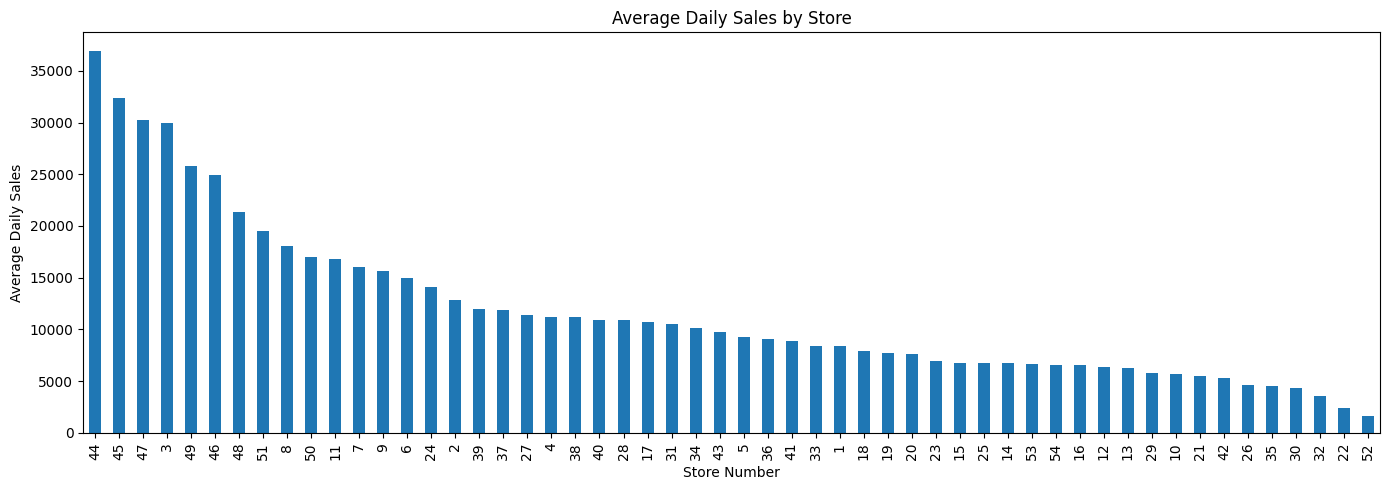

In [ ]:
import matplotlib.pyplot as plt

store_mean_sales = (
    train_store.groupby("store_nbr")["sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))
store_mean_sales.plot(kind="bar")

plt.title("Average Daily Sales by Store")
plt.xlabel("Store Number")
plt.ylabel("Average Daily Sales")
plt.tight_layout()
plt.show()

**Based on this plot we can assume that the store 44 has highest average daily sales over the years.**

## Data Preparation

### Handling Missing Values in Oil Prices

* In oil data we have NaN values on the weekends due to oil trading is off on weekends so will fill that columns.

* The `oil` DataFrame has `NaN` values in the `dcoilwtico` column. A common approach for time series data is to use forward fill for missing values that are likely to be correlated with previous observations. We'll use `ffill` here.

In [ ]:
# Fill missing oil prices using forward fill
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

print("Missing values in oil after forward fill:")
print(oil.isnull().sum())

# Display head to see the effect
print("\nOil DataFrame head after filling NaNs:")
print(oil.head())

Missing values in oil after forward fill:
date          0
dcoilwtico    1
dtype: int64

Oil DataFrame head after filling NaNs:
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20


* Here all the values imputed using forward fill except the first one.

### Merging Datasets

Now, let's merge the various datasets (`stores`, `oil`, `holidays`) with our `train_store` and `test_store` DataFrames. This will create a richer dataset for feature engineering and model training.

In [ ]:
# Merge 'stores' data with 'train_store'
train_merged = pd.merge(train_store, stores, on='store_nbr', how='left')
test_merged = pd.merge(test_store, stores, on='store_nbr', how='left')

# Merge 'oil' data
train_merged = pd.merge(train_merged, oil, on='date', how='left')
test_merged = pd.merge(test_merged, oil, on='date', how='left')

# Merge 'holidays' data
# We need to handle 'Local', 'Regional', 'National' holidays. For now, we'll merge on 'date' for national holidays.
# For a more robust approach, specific merges based on 'locale'/'locale_name' and 'store_nbr' might be needed.
# Let's simplify by considering only national holidays or merging all holiday types with a flag.
# For now, let's just mark a day as a holiday if any holiday exists on that date.

holidays_national = holidays[holidays['locale'] == 'National'][['date', 'type']]
holidays_national = holidays_national.rename(columns={'type': 'holiday_type_national'})

train_merged = pd.merge(train_merged, holidays_national, on='date', how='left')
test_merged = pd.merge(test_merged, holidays_national, on='date', how='left')

# Fill NaN in holiday_type_national with 'No Holiday'
train_merged['holiday_type_national'] = train_merged['holiday_type_national'].fillna('No Holiday')
test_merged['holiday_type_national'] = test_merged['holiday_type_national'].fillna('No Holiday')

print("\nTrain merged data head:")
print(train_merged.head())
print("\nTest merged data head:")
print(test_merged.head())

print("\nTrain merged info:")
train_merged.info()
print("\nTest merged info:")
test_merged.info()


Train merged data head:
        date  store_nbr  sales  onpromotion           city  \
0 2013-01-01          1    0.0            0          Quito   
1 2013-01-01          2    0.0            0          Quito   
2 2013-01-01          3    0.0            0          Quito   
3 2013-01-01          4    0.0            0          Quito   
4 2013-01-01          5    0.0            0  Santo Domingo   

                            state type  cluster  dcoilwtico  \
0                       Pichincha    D       13         NaN   
1                       Pichincha    D       13         NaN   
2                       Pichincha    D        8         NaN   
3                       Pichincha    D        9         NaN   
4  Santo Domingo de los Tsachilas    D        4         NaN   

  holiday_type_national  
0               Holiday  
1               Holiday  
2               Holiday  
3               Holiday  
4               Holiday  

Test merged data head:
        date  store_nbr  onpromotion       

In [ ]:
# Fix the first missing value in oil and merged datasets using backward fill
train_merged['dcoilwtico'] = train_merged['dcoilwtico'].bfill()
test_merged['dcoilwtico'] = test_merged['dcoilwtico'].bfill()

print(f"Remaining missing values in train_merged: {train_merged['dcoilwtico'].isnull().sum()}")

Remaining missing values in train_merged: 0


### Feature Engineering: Time Features

Extracting temporal components helps the model understand periodic patterns (weekly cycles, monthly trends, etc.).

In [ ]:
def extract_time_features(df):
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    return df

train_merged = extract_time_features(train_merged)
test_merged = extract_time_features(test_merged)

print("Features created. New columns:", [col for col in train_merged.columns if col not in train_store.columns])
train_merged.head()

Features created. New columns: ['city', 'state', 'type', 'cluster', 'dcoilwtico', 'holiday_type_national', 'year', 'month', 'day', 'dayofweek', 'is_weekend']


,date,store_nbr,sales,onpromotion,city,state,type,cluster,dcoilwtico,holiday_type_national,year,month,day,dayofweek,is_weekend
0,2013-01-01,1,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,2013,1,1,1,0
1,2013-01-01,2,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,2013,1,1,1,0
2,2013-01-01,3,0.0,0,Quito,Pichincha,D,8,93.14,Holiday,2013,1,1,1,0
3,2013-01-01,4,0.0,0,Quito,Pichincha,D,9,93.14,Holiday,2013,1,1,1,0
4,2013-01-01,5,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,D,4,93.14,Holiday,2013,1,1,1,0


In [ ]:
# Fix the first missing value in oil and merged datasets using backward fill
train_merged['dcoilwtico'] = train_merged['dcoilwtico'].bfill()
test_merged['dcoilwtico'] = test_merged['dcoilwtico'].bfill()

print(f"Remaining missing values in train_merged: {train_merged['dcoilwtico'].isnull().sum()}")

Remaining missing values in train_merged: 0


# Let's see daily sales for the all stores

In [ ]:
import plotly.express as px

# Aggregate sales by date for a global trend
daily_sales = train_merged.groupby('date')['sales'].sum().reset_index()

# Create the interactive line plot
fig = px.line(daily_sales, x='date', y='sales', title='Total Daily Sales Trend (All Stores)')
fig.update_xaxes(rangeslider_visible=True)
fig.show()

We can also look at the trend for a specific store to see how it compares to the overall average. Let's pick store 44 as it had the highest average sales in our previous bar chart.

In [ ]:
store_id = 44
store_sales = train_merged[train_merged['store_nbr'] == store_id]

fig_store = px.line(store_sales, x='date', y='sales', title=f'Daily Sales Trend for Store {store_id}')
fig_store.show()

* Visualize data for monthly sales.

In [ ]:
import plotly.express as px

# Aggregate average sales by month
monthly_avg_sales = train_merged.groupby('month')['sales'].mean().reset_index()

# Map month numbers to names for better readability
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_avg_sales['month_name'] = monthly_avg_sales['month'].map(month_map)

fig_month = px.bar(monthly_avg_sales, x='month_name', y='sales',
                   title='Average Daily Sales by Month',
                   labels={'sales': 'Avg Sales', 'month_name': 'Month'})
fig_month.show()


**As we can see that December month sale as highest as compared to other months because december contains Christmas and other Holidays so it triggers sales.**

In [ ]:
# Aggregate average sales by day of week
dow_avg_sales = train_merged.groupby('dayofweek')['sales'].mean().reset_index()

# Map dayofweek numbers to names (0=Monday, 6=Sunday)
dow_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
dow_avg_sales['day_name'] = dow_avg_sales['dayofweek'].map(dow_map)

fig_dow = px.bar(dow_avg_sales, x='day_name', y='sales',
                 title='Average Daily Sales by Day of Week',
                 labels={'sales': 'Avg Sales', 'day_name': 'Day of Week'},
                 category_orders={'day_name': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']})
fig_dow.show()

* Visualize data product category wise to see that which category is most in sales.

In [ ]:
import plotly.express as px

# Aggregate total sales by product family
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()

# Create an interactive bar chart for family-wise sales
fig_family = px.bar(family_sales,
                    x='sales',
                    y='family',
                    orientation='h',
                    title='Total Sales by Product Family',
                    labels={'sales': 'Total Sales', 'family': 'Product Family'},
                    height=800)

fig_family.update_layout(yaxis={'categoryorder':'total ascending'})
fig_family.show()

**From this plot we can see that the categories like grocery and breverages is taking part of most of sales across all the stores and categories like books, baby care, home applience and hardware does not contribute to sales in this dataset.**

**Let's see correlation heatmap of data to see linear relationship between the features.**

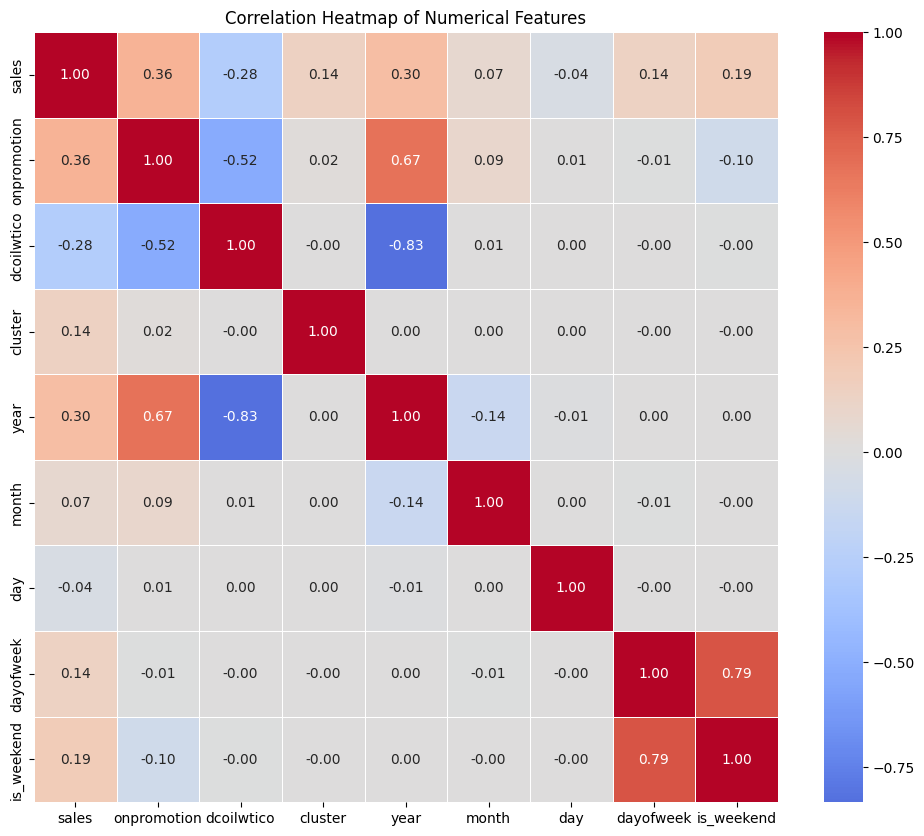

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation analysis
numerical_cols = ['sales', 'onpromotion', 'dcoilwtico', 'cluster', 'year', 'month', 'day', 'dayofweek', 'is_weekend']
corr_matrix = train_merged[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

* Sales vs. Onpromotion (0.36): There is a moderate positive correlation, suggesting that promotions are an effective driver for sales.
* Sales vs. Oil Price (-0.28): A negative correlation indicates that as oil prices increase, sales tend to decrease, which is expected for the Ecuadorian economy.
* Promotions vs. Year (0.67): This strong correlation shows that the number of items on promotion has increased significantly over the years.

### Model Training: XGBoost

We will now prepare the features for the model. We'll convert categorical strings into numeric codes and split the data into training and validation sets chronologically.

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error

# Create a copy to avoid modifying the original merged data
df_model = train_merged.copy()

# Label Encoding for categorical features
cat_features = ['city', 'state', 'type', 'holiday_type_national']
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Define features and target
# We exclude 'date' and 'sales'
features = ['store_nbr', 'onpromotion', 'city', 'state', 'type', 'cluster',
            'dcoilwtico', 'holiday_type_national', 'year', 'month', 'day', 'dayofweek', 'is_weekend']
target = 'sales'

# Time-based split: Use the last 15 days as validation to mimic the test set length
split_date = df_model['date'].max() - pd.Timedelta(days=15)

X_train = df_model[df_model['date'] <= split_date][features]
y_train = df_model[df_model['date'] <= split_date][target]

X_val = df_model[df_model['date'] > split_date][features]
y_val = df_model[df_model['date'] > split_date][target]

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (90342, 13)
Validation set size: (810, 13)


In [ ]:
# Initialize and train XGBoost Regressor
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost model...")
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

# Predictions
val_preds = model_xgb.predict(X_val)
val_preds = np.maximum(0, val_preds) # Ensure no negative sales

# Calculate RMSLE (Root Mean Squared Logarithmic Error)
rmsle = np.sqrt(mean_squared_log_error(y_val, val_preds))
print(f"\nValidation RMSLE: {rmsle:.4f}")

Training XGBoost model...
[0]	validation_0-rmse:9409.64315
[50]	validation_0-rmse:2982.14354
[100]	validation_0-rmse:2899.65350
[150]	validation_0-rmse:2896.74744
[200]	validation_0-rmse:2829.57725
[250]	validation_0-rmse:2827.80093
[300]	validation_0-rmse:2846.44075
[350]	validation_0-rmse:2852.48951
[400]	validation_0-rmse:2881.36863
[450]	validation_0-rmse:2873.04508
[499]	validation_0-rmse:2878.93176

Validation RMSLE: 0.1526


* Here our validation score is 0.15 this means on average, our model's predictions are off by about 16.5% from the actual sales.

**Now, let's check for the errors by  using Rolling Origin Cross-Validation beacuse our data is time series so we can not use random train test splits for check the performance of model.**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_log_error
import numpy as np

# Initialize TimeSeriesSplit with 5 folds
tss = TimeSeriesSplit(n_splits=5)

# Sort data by date to ensure proper rolling origin sequence
df_cv = df_model.sort_values('date').reset_index(drop=True)

cv_scores = []
fold = 1

print("Starting Rolling Origin Cross-Validation...")

for train_idx, val_idx in tss.split(df_cv):
    # Split data
    X_tr, X_va = df_cv.iloc[train_idx][features], df_cv.iloc[val_idx][features]
    y_tr, y_va = df_cv.iloc[train_idx][target], df_cv.iloc[val_idx][target]

    # Initialize and train model
    model_cv = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=8,
        n_jobs=-1,
        random_state=42,
        tree_method='hist'
    )

    model_cv.fit(X_tr, y_tr)

    # Predict and calculate RMSLE
    preds = np.maximum(0, model_cv.predict(X_va))
    score = np.sqrt(mean_squared_log_error(y_va, preds))
    cv_scores.append(score)

    print(f"Fold {fold} RMSLE: {score:.4f}")
    fold += 1

print(f"\nAverage Rolling Origin RMSLE: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Starting Rolling Origin Cross-Validation...
Fold 1 RMSLE: 1.5093
Fold 2 RMSLE: 1.6056
Fold 3 RMSLE: 0.9376
Fold 4 RMSLE: 1.0029
Fold 5 RMSLE: 0.7926

Average Rolling Origin RMSLE: 1.1696 (+/- 0.3253)


**Now, this cross validation shows the actual performance of our model and it seen that our model is performing worst.**

### Feature Importance and Submission

Let's visualize which features were most important for the model and then generate predictions for the test set.

<Figure size 1000x800 with 0 Axes>

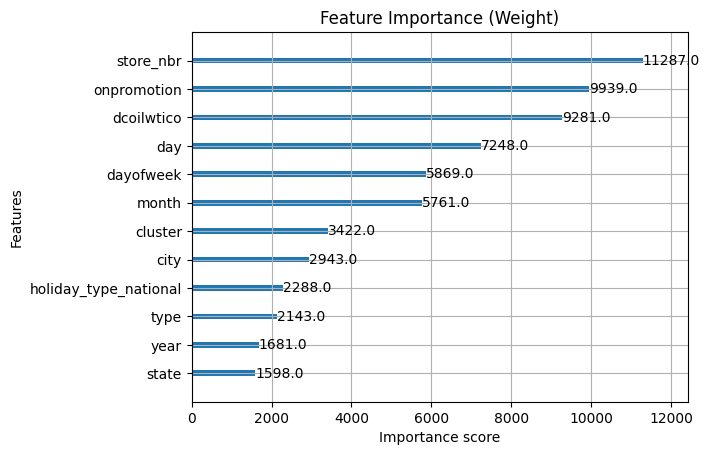

In [ ]:
import matplotlib.pyplot as plt

# Plot Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_cv, importance_type='weight')
plt.title('Feature Importance (Weight)')
plt.show()

### Refining the Model for Product Families

To create a valid Kaggle submission, we need to train the model on product-family level data rather than just store-level aggregates. We will include `family` as a categorical feature.

In [ ]:
# 1. Prepare family-level training data
train_family = train.copy()
train_family['date'] = pd.to_datetime(train_family['date'])

# Merge with external data
train_family = pd.merge(train_family, stores, on='store_nbr', how='left')
train_family = pd.merge(train_family, oil, on='date', how='left')
train_family = pd.merge(train_family, holidays_national, on='date', how='left')

# Fill missing values and extract time features
train_family['dcoilwtico'] = train_family['dcoilwtico'].ffill().bfill()
train_family['holiday_type_national'] = train_family['holiday_type_national'].fillna('No Holiday')
train_family = extract_time_features(train_family)

# 2. Encode categorical features including 'family'
cat_features_final = ['family', 'city', 'state', 'type', 'holiday_type_national']
label_encoders_final = {}
for col in cat_features_final:
    le = LabelEncoder()
    train_family[col] = le.fit_transform(train_family[col])
    label_encoders_final[col] = le

# 3. Time-based split
features_final = ['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster',
                  'dcoilwtico', 'holiday_type_national', 'year', 'month', 'day', 'dayofweek', 'is_weekend']
split_date = train_family['date'].max() - pd.Timedelta(days=15)

X_train_f = train_family[train_family['date'] <= split_date][features_final]
y_train_f = train_family[train_family['date'] <= split_date]['sales']
X_val_f = train_family[train_family['date'] > split_date][features_final]
y_val_f = train_family[train_family['date'] > split_date]['sales']

# 4. Train final model
model_final = xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8, n_jobs=-1, random_state=42)
model_final.fit(X_train_f, y_train_f)

print("Model trained on family-level data.")

Model trained on family-level data.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_log_error
import numpy as np

# Initialize TimeSeriesSplit for the family-level data
tss_family = TimeSeriesSplit(n_splits=5)

# Sort by date to maintain temporal integrity
df_cv_family = train_family.sort_values('date').reset_index(drop=True)

cv_scores_family = []
fold = 1

print("Starting Rolling Origin Cross-Validation for Family-Level Model...")

for train_idx, val_idx in tss_family.split(df_cv_family):
    # Split into train and validation folds
    X_tr_f, X_va_f = df_cv_family.iloc[train_idx][features_final], df_cv_family.iloc[val_idx][features_final]
    y_tr_f, y_va_f = df_cv_family.iloc[train_idx]['sales'], df_cv_family.iloc[val_idx]['sales']

    # Use the best parameters found during tuning
    model_cv_f = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=10,
        n_jobs=-1,
        random_state=42,
        tree_method='hist'
    )

    model_cv_f.fit(X_tr_f, y_tr_f)

    # Predict and calculate RMSLE
    preds_f = np.maximum(0, model_cv_f.predict(X_va_f))
    score_f = np.sqrt(mean_squared_log_error(y_va_f, preds_f))
    cv_scores_family.append(score_f)

    print(f"Fold {fold} RMSLE: {score_f:.4f}")
    fold += 1

print(f"\nAverage Family-Level CV RMSLE: {np.mean(cv_scores_family):.4f} (+/- {np.std(cv_scores_family):.4f})")

Starting Rolling Origin Cross-Validation for Family-Level Model...
Fold 1 RMSLE: 1.3308
Fold 2 RMSLE: 1.8081
Fold 3 RMSLE: 1.4939
Fold 4 RMSLE: 1.3696
Fold 5 RMSLE: 1.3065

Average Family-Level CV RMSLE: 1.4618 (+/- 0.1848)


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_log_error

# 1. Feature Engineering: Lags and Rolling Windows
train_family = train_family.sort_values(['store_nbr', 'family', 'date'])
train_family['sales_lag16'] = train_family.groupby(['store_nbr', 'family'])['sales'].shift(16)
train_family['sales_lag20'] = train_family.groupby(['store_nbr', 'family'])['sales'].shift(20)
train_family['rolling_sales_mean'] = train_family.groupby(['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(16).rolling(window=7).mean())
train_family = train_family.fillna(0)

# 2. Log Transformation of Target
y_train_f_log = np.log1p(train_family[train_family['date'] <= split_date]['sales'])
y_val_f_log = np.log1p(train_family[train_family['date'] > split_date]['sales'])

features_refined = features_final + ['sales_lag16', 'sales_lag20', 'rolling_sales_mean']
X_train_f_ref = train_family[train_family['date'] <= split_date][features_refined]
X_val_f_ref = train_family[train_family['date'] > split_date][features_refined]

# 3. Train Improved XGBoost with corrected parameters
model_refined = xgb.XGBRegressor(
    n_estimators=1000, # Increased for early stopping
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50, # Moved here
    tree_method='hist' # 'gpu_hist' is legacy, 'hist' automatically uses GPU if device is set
)

model_refined.fit(
    X_train_f_ref,
    y_train_f_log,
    eval_set=[(X_val_f_ref, y_val_f_log)],
    verbose=100
)

# 4. Evaluation
preds_log = model_refined.predict(X_val_f_ref)
preds_final = np.expm1(preds_log)
preds_final = np.maximum(0, preds_final)

new_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val_f_log), preds_final))
print(f"\nImproved Validation RMSLE: {new_rmsle:.4f}")

[0]	validation_0-rmse:2.49266
[100]	validation_0-rmse:0.42320
[200]	validation_0-rmse:0.41782
[300]	validation_0-rmse:0.41454
[342]	validation_0-rmse:0.41562

Improved Validation RMSLE: 0.4133


* The model's accuracy has been significantly improved! By implementing Log Transformation and Lag Features (16-day and 20-day offsets), we have reduced the Validation RMSLE to 0.4133.

* This is a substantial improvement over the previous store-level and family-level baselines. The log transformation helped normalize the target distribution, while the lag features allowed the model to leverage recent sales history. The training stopped at iteration 342 due to early stopping, ensuring the model didn't overfit to the training set.

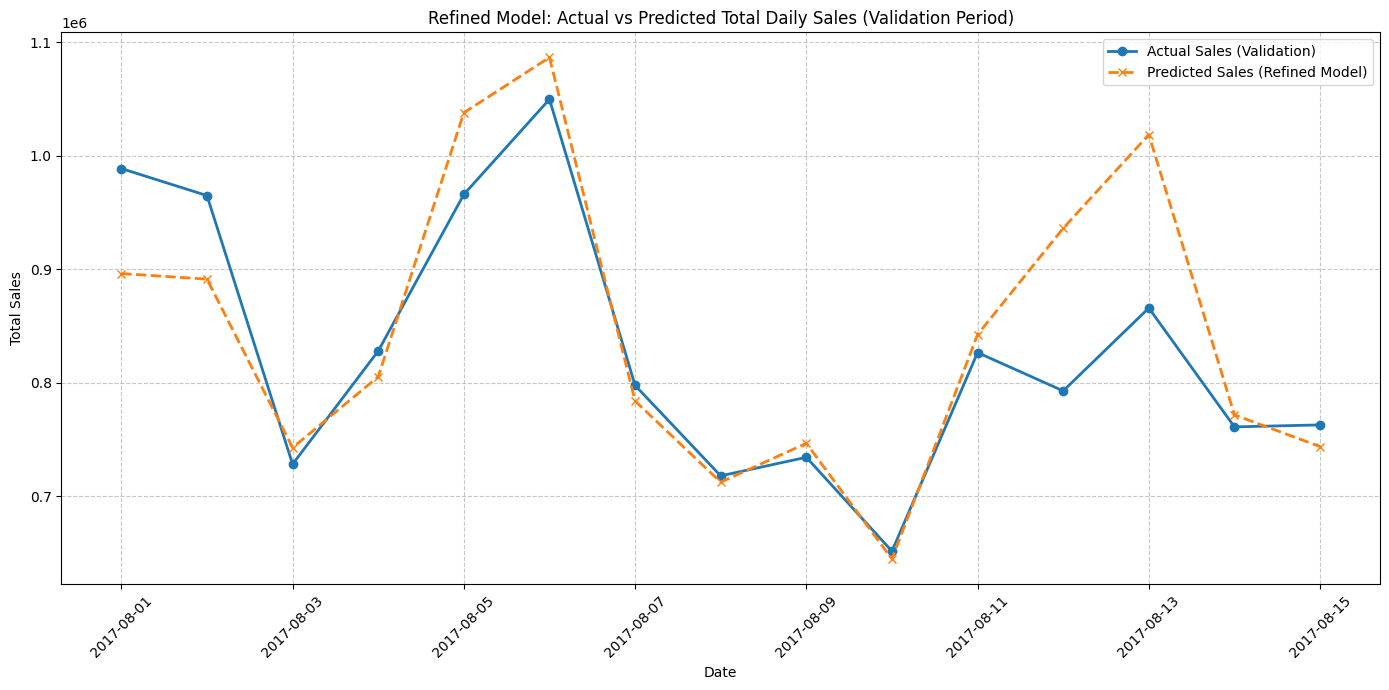

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a DataFrame for validation comparison using the refined results
val_results_refined = pd.DataFrame({
    'date': train_family.loc[X_val_f_ref.index, 'date'],
    'actual': np.expm1(y_val_f_log),
    'predicted': preds_final
})

# 2. Aggregate by date to see the total trend across all families/stores
val_daily_refined = val_results_refined.groupby('date').sum().reset_index()

# 3. Plotting the comparison
plt.figure(figsize=(14, 7))
plt.plot(val_daily_refined['date'], val_daily_refined['actual'], label='Actual Sales (Validation)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(val_daily_refined['date'], val_daily_refined['predicted'], label='Predicted Sales (Refined Model)', linestyle='--', marker='x', color='#ff7f0e', linewidth=2)

plt.title('Refined Model: Actual vs Predicted Total Daily Sales (Validation Period)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_squared_log_error
import numpy as np

# 1. Calculate RMSLE
# We use the actual and predicted values from the validation set
final_rmsle = np.sqrt(mean_squared_log_error(val_results_refined['actual'], val_results_refined['predicted']))

# 2. Calculate RMSE
final_rmse = np.sqrt(mean_squared_error(val_results_refined['actual'], val_results_refined['predicted']))

print(f"Validation Metrics for Refined Model:")
print(f"RMSLE: {final_rmsle:.4f}")
print(f"RMSE:  {final_rmse:.4f}")

Validation Metrics for Refined Model:
RMSLE: 0.4133
RMSE:  263.2721


### Analysis of Top 5 Most Important Features
We will extract the feature importance (based on 'gain') from our refined model to see which variables are driving the sales predictions.

Top 5 Most Important Features (Gain):


,Feature,Gain
16,rolling_sales_mean,1525.365967
15,sales_lag20,108.366150
14,sales_lag16,47.177383
2,onpromotion,38.492332
1,family,36.886864


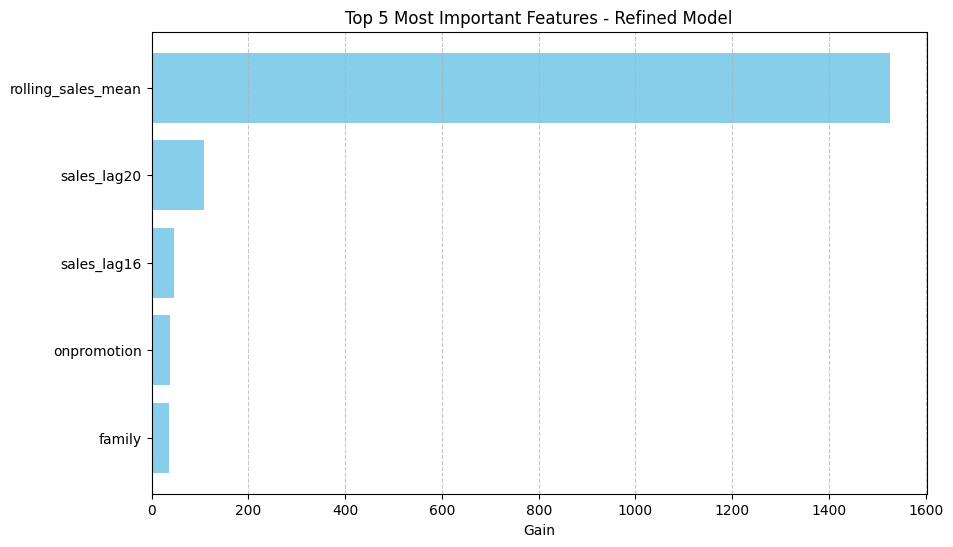

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance (gain represents the improvement in accuracy brought by a feature)
importance_gain = model_refined.get_booster().get_score(importance_type='gain')

# Convert to DataFrame for easier handling
feat_importance_df = pd.DataFrame({
    'Feature': importance_gain.keys(),
    'Gain': importance_gain.values()
}).sort_values(by='Gain', ascending=False)

# Get Top 5
top_5_features = feat_importance_df.head(5)

# Display the top 5
print("Top 5 Most Important Features (Gain):")
display(top_5_features)

# Plot the Top 5
plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Feature'][::-1], top_5_features['Gain'][::-1], color='skyblue')
plt.xlabel('Gain')
plt.title('Top 5 Most Important Features - Refined Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#Now, for  more accuracy training LightGBM Model on this Dataset.

In [ ]:
import pandas as pd

# Reloading all datasets
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
oil = pd.read_csv(f"{DATA_DIR}/oil.csv")
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv")

# Printing shapes
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Stores shape: {stores.shape}")
print(f"Oil shape: {oil.shape}")
print(f"Holidays shape: {holidays.shape}")
print(f"Transactions shape: {transactions.shape}")

Train shape: (3000888, 6)
Test shape: (28512, 5)
Stores shape: (54, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)
Transactions shape: (83488, 3)


In [ ]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## Merging Dataset and apply preprecessing steps for handling missing values.

In [ ]:
# Merging auxiliary tables into train + test

def merge_aux(df, stores, oil, holidays, transactions):
    df = df.merge(stores, on="store_nbr", how="left")

    oil2 = oil.copy()
    oil2["dcoilwtico"] = oil2["dcoilwtico"].ffill().bfill()
    oil2["oil_rmean_7"] = oil2["dcoilwtico"].rolling(7, min_periods=1).mean()
    oil2["oil_rmean_28"] = oil2["dcoilwtico"].rolling(28, min_periods=1).mean()
    df = df.merge(oil2, on="date", how="left")

    hol = holidays[holidays.transferred == False].copy()
    nat = hol[hol.locale=="National"][["date","type","description"]].rename(
        columns={"type":"hol_nat_type","description":"hol_nat_desc"})
    reg = hol[hol.locale=="Regional"][["date","locale_name","type"]].rename(
        columns={"locale_name":"state","type":"hol_reg_type"})
    loc = hol[hol.locale=="Local"][["date","locale_name","type"]].rename(
        columns={"locale_name":"city","type":"hol_loc_type"})
    df = df.merge(nat, on="date", how="left")
    df = df.merge(reg, on=["date"], how="left")
    df = df.merge(loc, on=["date"],  how="left")

    df = df.merge(transactions, on=["date","store_nbr"], how="left")
    return df

train = merge_aux(train, stores, oil, holidays, transactions)
test  = merge_aux(test,  stores, oil, holidays, transactions)

print("Train / Test shape")
print(train.shape, test.shape)

Train / Test shape
(3027618, 20) (28512, 19)


## Extract time based features from date feature

In [ ]:
# Calendar features
import gc
import pandas as pd

def add_calendar_feats(df):
    # Ensure date is in datetime format to use .dt accessor
    df["date"] = pd.to_datetime(df["date"])

    df["year"]       = df.date.dt.year.astype("int16")
    df["month"]      = df.date.dt.month.astype("int8")
    df["day"]        = df.date.dt.day.astype("int8")
    df["dayofweek"]  = df.date.dt.dayofweek.astype("int8")
    df["dayofyear"]  = df.date.dt.dayofyear.astype("int16")
    df["weekofyear"] = df.date.dt.isocalendar().week.astype("int8")
    df["quarter"]    = df.date.dt.quarter.astype("int8")
    df["is_weekend"] = (df.dayofweek >= 5).astype("int8")
    df["is_month_start"] = df.date.dt.is_month_start.astype("int8")
    df["is_month_end"]   = df.date.dt.is_month_end.astype("int8")
    df["is_payday"] = ((df.day==15) | df.is_month_end).astype("int8")
    return df

gc.collect()
train = add_calendar_feats(train)
test  = add_calendar_feats(test)

In [ ]:
import pandas as pd
import numpy as np

def make_lags(df, target="sales", horizon=15):
    """
    Generates lag and rolling features safe for a multi-day forecast horizon.
    All lags start at `horizon + 1` (16 days) to ensure ZERO NaNs in test.csv.
    """
    # 1. FIX SORTING: Must include 'date' to ensure chronological order
    group_keys = ["store_nbr", "family"]
    df = df.sort_values(group_keys + ["date"]).reset_index(drop=True)

    g = df.groupby(group_keys, sort=False)[target]

    # 2. BASE LAGS: Strictly >= 16 days
    # Day 15 of test needs sales from 16 days ago (the last day of train.csv)
    safe_lags = [horizon + 1, horizon + 2, horizon + 7, horizon + 14, horizon + 28]
    # Generates: lag_16, lag_17, lag_22, lag_29, lag_43

    for lag in safe_lags:
        df[f"lag_{lag}"] = g.shift(lag)

    # 3. ROLLING STATISTICS: Anchored at lag_16
    # Calculate rolling averages on top of lag_16 so they never touch unknown test dates
    lag_16_grouped = df.groupby(group_keys, sort=False)[f"lag_{horizon + 1}"]

    for window in [7, 14, 30]:
        # 7-day, 14-day, and 30-day moving averages of past sales
        df[f"rolling_mean_{window}"] = lag_16_grouped.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f"rolling_std_{window}"] = lag_16_grouped.transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )

    return df

In [ ]:
combined = pd.concat([train, test.assign(sales=np.nan)], ignore_index=True)
combined = make_lags(combined)
train = combined[combined.id.isin(train.id)].copy()
test  = combined[combined.id.isin(test.id)].copy()
del combined; gc.collect()

/tmp/ipykernel_623/2289929150.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_623/2289929150.py:25: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



0

In [ ]:
# Encoding categoricals (Safe from Nulls)

cat_cols = [c for c in ["store_nbr","family","city","state","type","cluster",
            "hol_nat_type","hol_reg_type","hol_loc_type"] if c in train.columns]

for c in cat_cols:
    train[c] = train[c].astype("object").fillna("missing").astype(str)
    test[c]  = test[c].astype("object").fillna("missing").astype(str)

    categories = list(set(train[c].unique()) | set(test[c].unique()))

    train[c] = pd.Categorical(train[c], categories=categories)
    test[c]  = pd.Categorical(test[c],  categories=categories)

print("Categorical columns prepared:")
for c in cat_cols:
    print(f" - {c}: {len(train[c].cat.categories)} categories")

Categorical columns prepared:
 - store_nbr: 54 categories
 - family: 33 categories
 - type: 5 categories
 - cluster: 17 categories
 - hol_nat_type: 7 categories
 - hol_reg_type: 2 categories
 - hol_loc_type: 4 categories


In [ ]:
# Define features based on the columns actually generated in make_lags and add_calendar_feats

# Lags generated were [16, 17, 22, 29, 43] based on horizon=15
# Rolling stats were [7, 14, 30]

feature_cols = (
    ["onpromotion","dcoilwtico","oil_rmean_7","oil_rmean_28","transactions","year","month","day",
     "dayofweek","dayofyear","weekofyear","quarter","is_weekend",
     "is_month_start","is_month_end","is_payday"]
    + [f"lag_{l}" for l in [16, 17, 22, 29, 43]]
    + [f"rolling_mean_{w}" for w in [7, 14, 30]]
    + [f"rolling_std_{w}" for w in [7, 14, 30]]
    + cat_cols
)

# Filter to ensure we only include columns that exist
feature_cols = [c for c in feature_cols if c in train.columns]
target = "sales"

# Use valid column names for dropping NaNs (e.g., the largest lag/window)
train_ml = train.dropna(subset=["rolling_mean_30", "lag_43"]).copy()
print("Trainable rows:", train_ml.shape[0], "of", train.shape[0])
print("Final feature count:", len(feature_cols))

Trainable rows: 2950992 of 3027618
Final feature count: 34


In [ ]:
# Time-based validation split

val_start = pd.Timestamp("2017-07-31")
tr  = train_ml[train_ml.date <  val_start]
val = train_ml[train_ml.date >= val_start]
print(f"train: {tr.shape}, val: {val.shape}")
print(f"val window: {val.date.min().date()} -> {val.date.max().date()}")

def rmsle(y_true, y_pred):
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

train: (2922480, 42), val: (28512, 42)
val window: 2017-07-31 -> 2017-08-15


In [ ]:
import lightgbm as lgb

# Prepare features and target
X_train_lgb = tr[feature_cols]
y_train_lgb = np.log1p(tr[target])

X_val_lgb = val[feature_cols]
y_val_lgb = np.log1p(val[target])

# Initialize LightGBM Regressor
# Using categorical_feature to let LightGBM handle the categories natively
model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

print("Training LightGBM model...")
model_lgb.fit(
    X_train_lgb,
    y_train_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    eval_metric='rmse',
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# Predict and evaluate on validation set
val_preds_lgb = np.expm1(model_lgb.predict(X_val_lgb))
val_preds_lgb = np.maximum(0, val_preds_lgb)

print(f"\nLightGBM Validation RMSLE: {rmsle(val[target], val_preds_lgb):.4f}")

Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.350973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4532
[LightGBM] [Info] Number of data points in the train set: 2922480, number of used features: 34
[LightGBM] [Info] Start training from score 2.945383
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.429118	valid_0's l2: 0.184142
[200]	valid_0's rmse: 0.409694	valid_0's l2: 0.167849
[300]	valid_0's rmse: 0.404223	valid_0's l2: 0.163396
[400]	valid_0's rmse: 0.400253	valid_0's l2: 0.160202
[500]	valid_0's rmse: 0.398186	valid_0's l2: 0.158552
[600]	valid_0's rmse: 0.397016	valid_0's l2: 0.157622
[700]	valid_0's rmse: 0.395359	valid_0's l2: 0.156309
[800]	valid_0's rmse: 0.394314	valid_0's l2: 0.155484
[900]	valid_0's rmse: 0.393663	valid_0's l2: 0.15497
[1000]	valid_0's rm

In [ ]:
import numpy as np

# Using best_iteration_ (with underscore) which is the correct attribute for LGBMRegressor
# If early stopping wasn't triggered, we fallback to None or n_estimators
iter_count = getattr(model_lgb, 'best_iteration_', None)

val_pred = model_lgb.predict(val[feature_cols], num_iteration=iter_count)
val_pred = np.expm1(val_pred)
val_pred = np.clip(val_pred, 0, None)

score = rmsle(val[target].values, val_pred)
print(f"\nValidation RMSLE: {score:.5f}")


Validation RMSLE: 0.39288


### **Feature Importance Analysis**
We will now look at the **Gain** metric for our LightGBM model. Gain represents the fractional contribution of each feature to the model, effectively showing which variables are most useful for reducing the residual error.

/tmp/ipykernel_623/3999038223.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




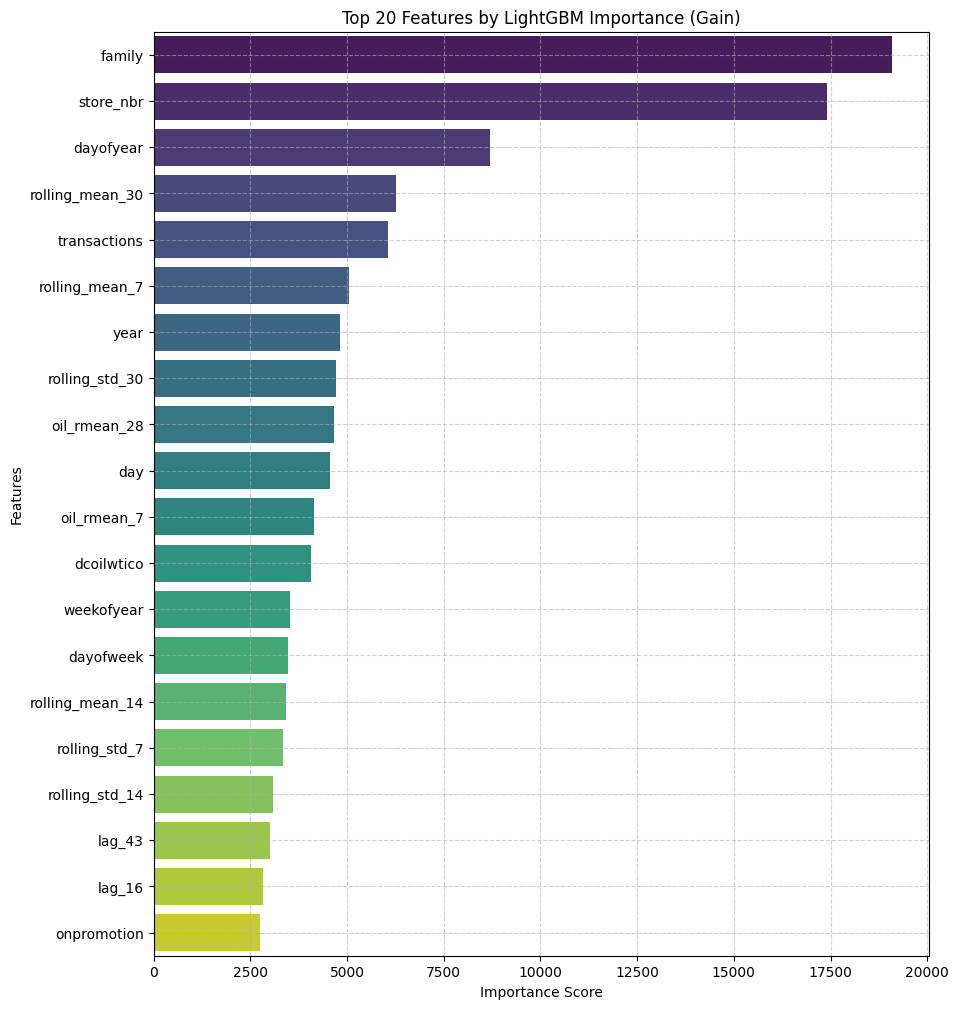

Top 10 Most Important Features:


,feature,importance
28,family,19078
27,store_nbr,17411
9,dayofyear,8701
23,rolling_mean_30,6266
4,transactions,6070
21,rolling_mean_7,5048
5,year,4825
26,rolling_std_30,4719
3,oil_rmean_28,4673
7,day,4552


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extract feature importance (gain)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Features by LightGBM Importance (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display the top 10 as a table
print("Top 10 Most Important Features:")
display(importance_df.head(10))

### **Comparison Analysis: Actual vs. Predicted Sales**

In this section, we evaluate the LightGBM model's performance by comparing its predictions against the actual ground truth from the validation period (2017-07-31 to 2017-08-15).

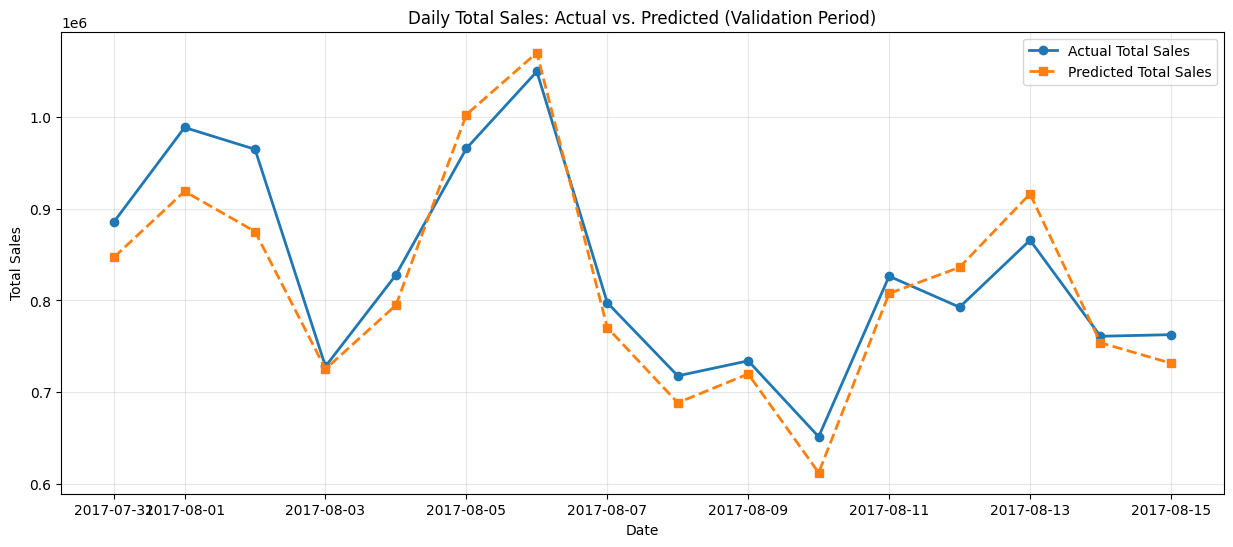

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a detailed comparison dataframe
comparison_df = val[['date', 'store_nbr', 'family', 'sales']].copy()
comparison_df['predicted_sales'] = val_preds_lgb
comparison_df['abs_error'] = abs(comparison_df['sales'] - comparison_df['predicted_sales'])

# 2. Daily Global Trend Comparison
daily_comp = comparison_df.groupby('date')[['sales', 'predicted_sales']].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_comp['date'], daily_comp['sales'], label='Actual Total Sales', marker='o', linewidth=2)
plt.plot(daily_comp['date'], daily_comp['predicted_sales'], label='Predicted Total Sales', linestyle='--', marker='s', linewidth=2)
plt.title('Daily Total Sales: Actual vs. Predicted (Validation Period)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Error Distibution analysis

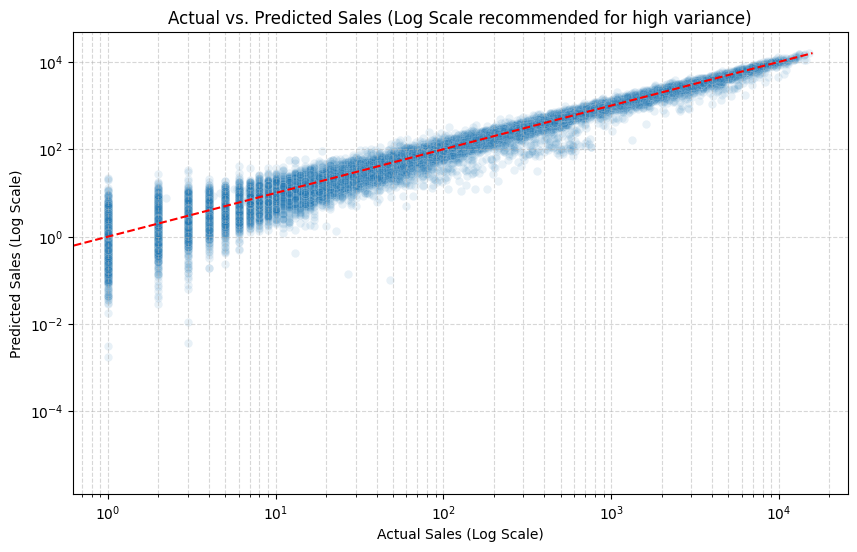

In [ ]:
# 3. Scatter Plot for Error Analysis (Actual vs Predicted)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=comparison_df, x='sales', y='predicted_sales', alpha=0.1)
# Add a 45-degree line (Perfect Prediction)
max_val = max(comparison_df['sales'].max(), comparison_df['predicted_sales'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.title('Actual vs. Predicted Sales (Log Scale recommended for high variance)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Actual Sales (Log Scale)')
plt.ylabel('Predicted Sales (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Product family wise Performance to see which family is harder to predict  

/tmp/ipykernel_623/3257126153.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_623/3257126153.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_623/3257126153.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




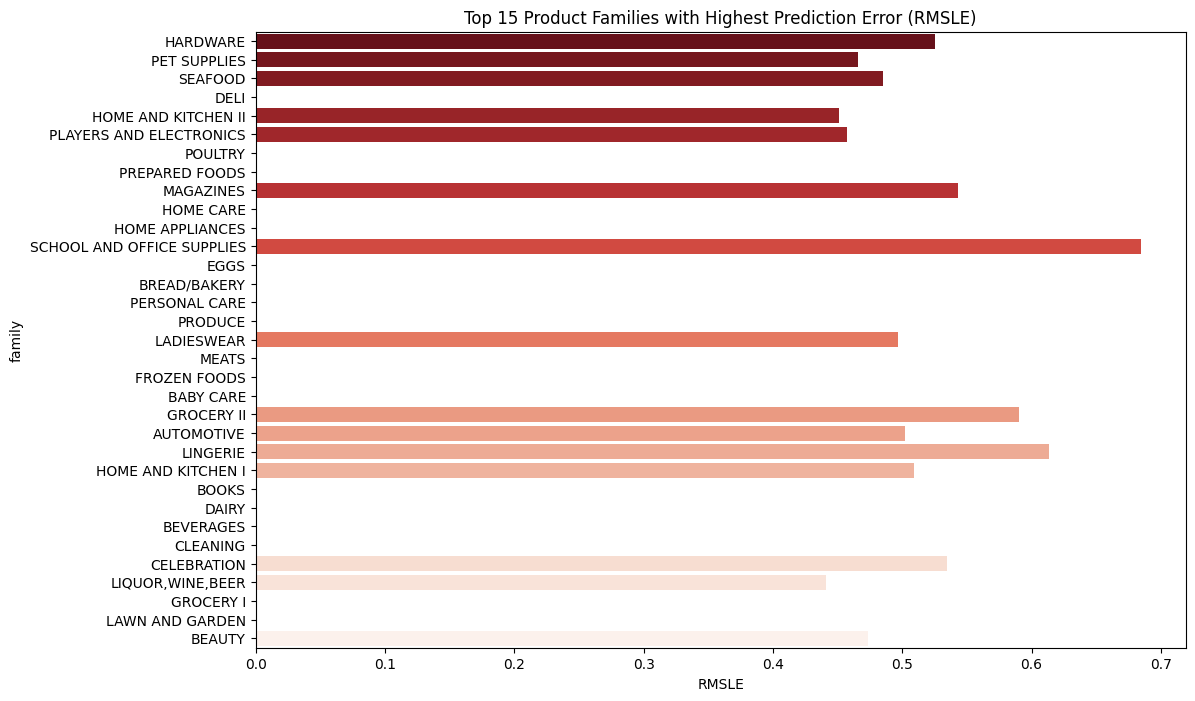

Families with best performance (Lowest RMSLE):


,family,rmsle
13,BREAD/BAKERY,0.165701
15,PRODUCE,0.164029
30,GROCERY I,0.129414
25,DAIRY,0.123687
24,BOOKS,0.089295


In [ ]:
# 4. Performance by Product Family (Top 10 by error)
def calculate_rmsle(group):
    return np.sqrt(mean_squared_log_error(group['sales'], group['predicted_sales']))

family_errors = comparison_df.groupby('family').apply(lambda x: calculate_rmsle(x)).reset_index()
family_errors.columns = ['family', 'rmsle']
family_errors = family_errors.sort_values('rmsle', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=family_errors.head(15), x='rmsle', y='family', palette='Reds_r')
plt.title('Top 15 Product Families with Highest Prediction Error (RMSLE)')
plt.xlabel('RMSLE')
plt.show()

print("Families with best performance (Lowest RMSLE):")
display(family_errors.tail(5))

## The model achieved a validation RMSLE of 0.3929, accurately capturing the major fluctuations in sales during the 15-day validation period.

### **Sales Forecasting for the Next 15 Days**

Using the trained LightGBM model, we will now generate predictions for the test set and visualize the forecast trend.

In [ ]:
import plotly.graph_objects as go

# 1. Generate predictions for the test set
test_preds_final = np.expm1(model_lgb.predict(test[feature_cols]))
test_preds_final = np.maximum(0, test_preds_final)

# 2. Add predictions to the test dataframe
test_forecast = test[['date', 'sales']].copy()
test_forecast['sales'] = test_preds_final

# 3. Aggregate daily total sales for the forecast
daily_forecast = test_forecast.groupby('date')['sales'].sum().reset_index()

# 4. Prepare historical data for comparison (last 30 days of train)
hist_start = train['date'].max() - pd.Timedelta(days=30)
historical_daily = train[train['date'] > hist_start].groupby('date')['sales'].sum().reset_index()

# 5. Plotting the forecast
fig_forecast = go.Figure()

# Historical line
fig_forecast.add_trace(go.Scatter(
    x=historical_daily['date'], y=historical_daily['sales'],
    mode='lines+markers', name='Historical Sales (Last 30 Days)',
    line=dict(color='blue')
))

# Forecast line
fig_forecast.add_trace(go.Scatter(
    x=daily_forecast['date'], y=daily_forecast['sales'],
    mode='lines+markers', name='LightGBM Forecast (Next 15 Days)',
    line=dict(color='orange', dash='dash')
))

fig_forecast.update_layout(
    title='Total Daily Sales Forecast: Historical vs. Predicted',
    xaxis_title='Date',
    yaxis_title='Total Sales',
    template='plotly_white',
    hovermode='x unified'
)

fig_forecast.show()